# Fashion-MNIST Dataset - CNN

### [Fashion-MNIST Dataset](https://github.com/zalandoresearch/fashion-mnist)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Han Xiao, Kashif Rasul, Roland Vollgraf, https://github.com/zalandoresearch/fashion-mnist

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy pandas matplotlib scikit-learn

## Import Libraries

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
IN_CHANNELS = 1
IN_CHANNELS

1

In [6]:
NUM_CLASSES = 10
NUM_CLASSES

10

In [7]:
IMAGE_SIZE = 28
IMAGE_SIZE

28

In [8]:
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
CLASS_NAMES

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

## Hyperparameters

In [9]:
LEARNING_RATE = 0.001
LEARNING_RATE

0.001

In [10]:
EPOCHS = 5
EPOCHS

5

In [11]:
BATCH_SIZE = 128
BATCH_SIZE

128

## Device

In [12]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Load Dataset

Fashion-MNIST is a real dataset of 70,000 grayscale clothing images. torchvision downloads it once into `data/` and normalizes each image.

In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))])
train_data = datasets.FashionMNIST('data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST('data', train=False, download=True, transform=transform)
len(train_data), len(test_data)

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 65.5k/26.4M [00:00<01:10, 371kB/s]

  1%|          | 197k/26.4M [00:00<00:33, 779kB/s] 

  1%|▏         | 393k/26.4M [00:00<00:21, 1.23MB/s]

  2%|▏         | 557k/26.4M [00:00<00:21, 1.23MB/s]

...

Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 12.1MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



(60000, 10000)

### Visualize a Sample

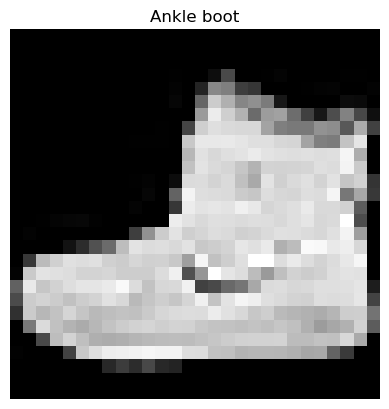

In [14]:
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(CLASS_NAMES[label])
plt.axis('off')
plt.show()

## Create Model

In [15]:
class CNN(nn.Module):
    """
    A small convolutional neural network for 28x28 grayscale images.
    """

    def __init__(self, num_classes=NUM_CLASSES):
        """
        Initialize the convolutional and dense layers.

        Parameters:
            num_classes (int): Number of output classes.

        Returns:
            None
        """
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        """
        Run the forward pass of the network.

        Parameters:
            x (torch.Tensor): Batch of images.

        Returns:
            torch.Tensor: Output logits.
        """
        x = self.features(x)
        return self.classifier(x)

## Instantiate Model

In [16]:
torch.manual_seed(SEED)
model = CNN().to(DEVICE)
model

CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

## Create DataLoaders

In [17]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(test_loader)

(469, 79)

## Create Loss Function & Optimizer

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Train Model

### Functions

In [19]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss for the epoch.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    """
    Evaluate the model over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.
        loss_fn (nn.Module): Loss function.

    Returns:
        tuple: Mean loss and accuracy.
    """
    model.eval()
    total, correct = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            total += loss_fn(logits, y).item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total / n, correct / n

### Training Loop

In [20]:
history = {'loss': [], 'accuracy': []}
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader, loss_fn)
    history['loss'].append(test_loss)
    history['accuracy'].append(test_accuracy)
    print(f"Epoch {epoch + 1} | train loss {train_loss:.4f} | test accuracy {test_accuracy:.4f}")

Epoch 1 | train loss 0.4970 | test accuracy 0.8677


Epoch 2 | train loss 0.3266 | test accuracy 0.8844


Epoch 3 | train loss 0.2806 | test accuracy 0.8886


Epoch 4 | train loss 0.2516 | test accuracy 0.8966


Epoch 5 | train loss 0.2316 | test accuracy 0.8992


### Visualize Training

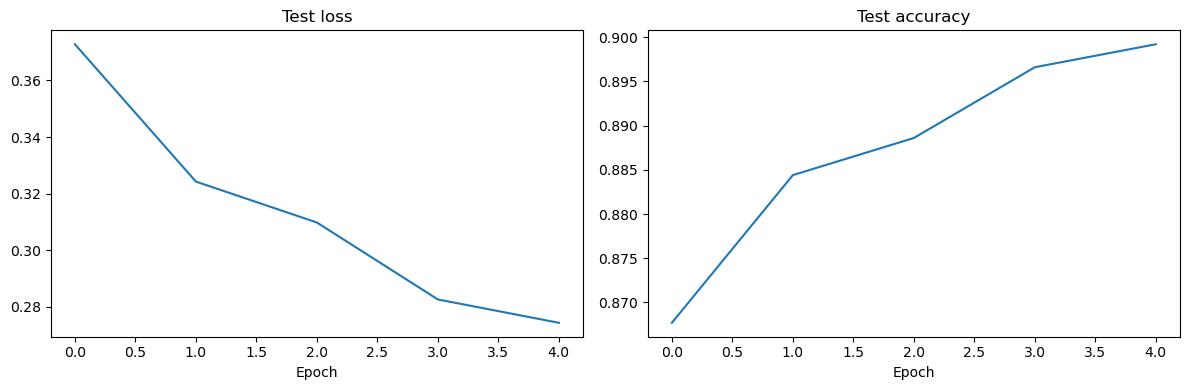

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['loss'])
axes[0].set_title('Test loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(history['accuracy'])
axes[1].set_title('Test accuracy')
axes[1].set_xlabel('Epoch')
fig.tight_layout()
plt.show()

## Evaluate Model

In [22]:
_, accuracy = evaluate(model, test_loader, loss_fn)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.8992


### Confusion Matrix and Classification Report

In [23]:
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        all_preds.append(model(x).argmax(1).cpu().numpy())
        all_labels.append(y.numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

[[776   0  11  16   6   1 185   0   5   0]
 [  1 982   0  10   4   0   2   0   1   0]
 [ 12   1 773   4 119   0  91   0   0   0]
 [  7   6  12 876  50   0  48   0   1   0]
 [  1   1  20   9 919   0  50   0   0   0]
 [  0   0   0   0   0 967   0  20   0  13]
 [ 52   1  36  21  90   0 798   0   2   0]
 [  0   0   0   0   0   9   0 951   0  40]
 [  4   2   2   3   3   1   6   4 975   0]
 [  0   0   0   0   0   4   1  20   0 975]]
              precision    recall  f1-score   support

 T-shirt/top       0.91      0.78      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.91      0.77      0.83      1000
       Dress       0.93      0.88      0.90      1000
        Coat       0.77      0.92      0.84      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.68      0.80      0.73      1000
     Sneaker       0.96      0.95      0.95      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.95     

## Save Model

In [24]:
torch.save(model.state_dict(), 'cnn_fashion_mnist.pt')
print('saved cnn_fashion_mnist.pt')

saved cnn_fashion_mnist.pt


## Load Model

In [25]:
loaded_model = CNN().to(DEVICE)
loaded_model.load_state_dict(torch.load('cnn_fashion_mnist.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded cnn_fashion_mnist.pt')

loaded cnn_fashion_mnist.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_55291/2230075774.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('cnn_

## Inference

### Function

In [26]:
def predict(model, image):
    """
    Predict the class of one normalized image tensor.

    Parameters:
        model (nn.Module): Trained model.
        image (torch.Tensor): A 1x28x28 image tensor.

    Returns:
        tuple: Predicted class name and confidence.
    """
    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(DEVICE))
        probs = torch.softmax(logits, dim=1)
        confidence, predicted = probs.max(dim=1)
    return CLASS_NAMES[predicted.item()], confidence.item()

### Run Inference

True: Shirt | Predicted: Shirt (0.9477)


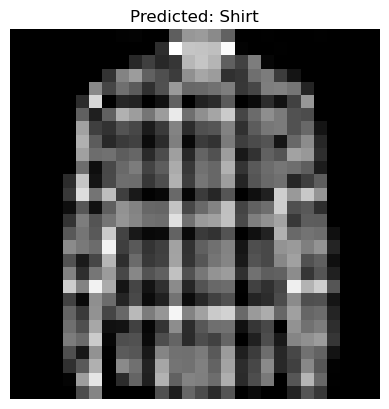

In [27]:
image, label = test_data[7]
name, confidence = predict(loaded_model, image)
print(f"True: {CLASS_NAMES[label]} | Predicted: {name} ({confidence:.4f})")
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Predicted: {name}")
plt.axis('off')
plt.show()